# 1. Setup and Imports

In [1]:
import pandas as pd
import psycopg2
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torchvision.models as models

warnings.filterwarnings('ignore')

# Database Connection
def get_db_connection():
    return psycopg2.connect(
        dbname="sih_db",
        user="parag",
        host="localhost",
        port="5432"
    )

conn = get_db_connection()
print("Libraries imported and DB connected!")

Libraries imported and DB connected!


# 2. Load Core Data (Pandas-First)
Fetch the tables directly into Pandas DataFrames so you can inspect them.

In [2]:
# 1. Reports and Labels
df_field_reports = pd.read_sql_query('SELECT * FROM field_reports;', conn)
df_lab_reports = pd.read_sql_query('SELECT * FROM lab_reports;', conn)
df_vet_verifs = pd.read_sql_query('SELECT * FROM vet_verifications;', conn)

# 2. Metadata Tables
df_diseases = pd.read_sql_query('SELECT * FROM diseases;', conn)
df_symptoms = pd.read_sql_query('SELECT * FROM symptoms;', conn)
df_species = pd.read_sql_query('SELECT * FROM species;', conn)

print(f"Loaded {len(df_field_reports)} Field Reports")
print(f"Loaded {len(df_lab_reports)} Lab Reports (Ground Truth)")
print(f"Loaded {len(df_vet_verifs)} Vet Verifications (Fallback Truth)")

# Let's inspect the field reports
display(df_field_reports.head(3))

Loaded 1000 Field Reports
Loaded 425 Lab Reports (Ground Truth)
Loaded 809 Vet Verifications (Fallback Truth)


,report_id,farmer_id,animal_species,photo_url,symptom_ids,latitude,longitude,reported_at
0,1757,174,Cattle,s3://bucket/img.jpg,"[1, 29, 30]",26.013869,92.029125,2026-09-03 00:05:38.376889
1,1758,201,Goat,s3://bucket/img.jpg,"[36, 37, 38, 39]",19.042489,73.040202,2026-09-03 00:05:38.376889
2,1759,371,Buffalo,s3://bucket/img.jpg,"[2, 56, 57, 58, 60, 61]",18.961661,73.002677,2026-09-03 00:05:38.376889


# 3. Data Preprocessing
Join the field reports with our 'truth' verifiers to build a labeled dataset.

In [3]:
# Merge Field Reports with Lab Reports for Ground Truth
# If no Lab Report exists, we'll try to fallback to Vet Verification

df_dataset = pd.merge(df_field_reports, df_lab_reports[['report_id', 'confirmed_disease_id']], on='report_id', how='left')

# Fallback to vet verification if lab is null
df_vet_subset = df_vet_verifs[['report_id', 'confirmed_disease_id']].rename(columns={'confirmed_disease_id': 'vet_disease_id'})
df_dataset = pd.merge(df_dataset, df_vet_subset, on='report_id', how='left')
df_dataset['target_disease_id'] = df_dataset['confirmed_disease_id'].fillna(df_dataset['vet_disease_id'])

# Drop rows where we have NO truth label
df_labeled = df_dataset.dropna(subset=['target_disease_id']).copy()

# One-Hot Encode the array of symptom_ids
mlb = MultiLabelBinarizer()
symptoms_encoded = mlb.fit_transform(df_labeled['symptom_ids'])
df_symptoms_features = pd.DataFrame(symptoms_encoded, columns=[f"symp_{c}" for c in mlb.classes_], index=df_labeled.index)

# One-Hot Encode species
df_species_features = pd.get_dummies(df_labeled['animal_species'], prefix='species', drop_first=True)

# Combine features (X) and target (y)
X = pd.concat([df_symptoms_features, df_species_features], axis=1)

# XGBoost requires target labels to be 0-indexed (e.g. 0 to N-1) instead of raw disease_ids (1 to N).
# We use LabelEncoder to map disease_ids to 0-indexed classes securely.
le = LabelEncoder()
y = le.fit_transform(df_labeled['target_disease_id'].astype(int))

print(f"Final training dataset size: {len(X)} labeled examples.")
display(X.head(3))

Final training dataset size: 895 labeled examples.


,symp_1,symp_2,symp_3,symp_4,symp_5,symp_6,symp_7,symp_8,symp_9,symp_10,...,symp_65,symp_66,symp_67,symp_68,symp_69,species_Cattle,species_Goat,species_Pig,species_Poultry,species_Sheep
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,False
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,False
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,False,False,False,False


# 4. Train Symptom Tabular Ensemble
Combine Random Forest, Gradient Boosting, Logistic Regression, and **XGBoost** using a Voting Classifier for robust predictions.

In [4]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Base Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Create an Ensemble Voting Classifier (soft voting averages the probabilities)
tabular_ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr), ('xgb', xgb)],
    voting='soft'
)

# Train the Ensemble
print("Training Tabular Ensemble Model (RF + GB + LR + XGBoost)...")
tabular_ensemble.fit(X_train, y_train)

# Predict and Evaluate
y_pred = tabular_ensemble.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Tabular Ensemble Model Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# Get probabilities for final multimodal ensemble
tabular_probs = tabular_ensemble.predict_proba(X_test)

Training Tabular Ensemble Model (RF + GB + LR + XGBoost)...
Tabular Ensemble Model Accuracy: 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        13
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        14

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



# 5. Final Triage & Confidence Scoring
Here we evaluate the final Confidence Scores for two scenarios: one relying only on tabular symptoms, and one blending in the CNN image analysis.

In [5]:
import numpy as np

def calculate_confidence(probs):
    """Returns the predicted class (0-indexed) and its confidence score."""
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    return preds, confs

no_image_preds, no_image_confs = calculate_confidence(tabular_probs)

print("=== FINAL TRIAGE RESULTS SUMMARY (FIRST 10 CASES) ===\n")

for i in range(min(10, len(X_test))):
    # Decode the 0-indexed ML prediction back into the actual SQL Database `disease_id`
    disease_id = le.inverse_transform([tabular_ensemble.classes_[no_image_preds[i]]])[0]

    print(f"Case {i+1}:")
    print(f"  -> Prediction: Disease ID {disease_id} (Confidence: {no_image_confs[i]*100:.1f}%)\n")

print(f"Overall Average Confidence: {np.mean(no_image_confs)*100:.1f}%")


=== FINAL TRIAGE RESULTS SUMMARY (FIRST 10 CASES) ===

Case 1:
  -> Prediction: Disease ID 11 (Confidence: 99.7%)

Case 2:
  -> Prediction: Disease ID 8 (Confidence: 97.5%)

Case 3:
  -> Prediction: Disease ID 4 (Confidence: 98.3%)

Case 4:
  -> Prediction: Disease ID 5 (Confidence: 95.1%)

Case 5:
  -> Prediction: Disease ID 9 (Confidence: 97.9%)

Case 6:
  -> Prediction: Disease ID 3 (Confidence: 99.5%)

Case 7:
  -> Prediction: Disease ID 11 (Confidence: 91.7%)

Case 8:
  -> Prediction: Disease ID 7 (Confidence: 99.2%)

Case 9:
  -> Prediction: Disease ID 2 (Confidence: 99.6%)

Case 10:
  -> Prediction: Disease ID 8 (Confidence: 69.2%)

Overall Average Confidence: 97.3%


# 6. Test with Custom Data\nInput your own custom species and symptoms list to see what the ensemble predicts!

In [6]:
# Let's test two scenarios: A contradictory edge-case, and an IDEAL perfect match!
test_cases = [
    {"name": "Contradictory Case (Mix of FMD and LSD)", "species": "Cattle", "symptoms": [28, 51]},
    {"name": "Ideal Case (Classic Lumpy Skin Disease)", "species": "Cattle", "symptoms": [35, 62, 63]} 
    # Note: 62=Skin nodules, 35=Fever, 63=Edema. Adjust these IDs if your DB IDs are slightly different!
]

print("=== CUSTOM PREDICTION TESTS ===\n")

for case in test_cases:
    print(f"--- {case['name']} ---")
    print(f"Input -> Species: {case['species']}, Symptoms: {case['symptoms']}")
    
    # 1. Transform symptoms
    # Use ignore strategy or catch error if symptom wasn't in training data
    try:
        symp_encoded = mlb.transform([case['symptoms']])
    except Exception as e:
        print(f"Error: Make sure all symptom IDs {case['symptoms']} actually exist in the training data!")
        continue
        
    df_custom_symp = pd.DataFrame(symp_encoded, columns=[f"symp_{c}" for c in mlb.classes_])
    
    # 2. Transform species
    df_custom_spec = pd.DataFrame(columns=[c for c in X.columns if c.startswith('species_')])
    df_custom_spec.loc[0] = 0
    species_col = f"species_{case['species']}"
    if species_col in df_custom_spec.columns:
        df_custom_spec.at[0, species_col] = 1
        
    # 3. Combine Features
    X_custom = pd.concat([df_custom_symp, df_custom_spec], axis=1)
    X_custom = X_custom[X.columns] # Ensure column order
    
    # 4. Predict
    custom_probs = tabular_ensemble.predict_proba(X_custom)
    pred_idx, conf = calculate_confidence(custom_probs)
    
    # Reverse LabelEncoder
    predicted_disease_id = le.inverse_transform([tabular_ensemble.classes_[pred_idx[0]]])[0]
    
    print(f"Predicted Disease ID: {predicted_disease_id}")
    print(f"Confidence: {conf[0]*100:.1f}%\n")


=== CUSTOM PREDICTION TESTS ===

--- Contradictory Case (Mix of FMD and LSD) ---
Input -> Species: Cattle, Symptoms: [28, 51]
Predicted Disease ID: 5
Confidence: 43.6%

--- Ideal Case (Classic Lumpy Skin Disease) ---
Input -> Species: Cattle, Symptoms: [35, 62, 63]
Predicted Disease ID: 11
Confidence: 94.4%



## 7. Spatial Outbreak Clustering (DBSCAN)
Now that we have trained our predictive model, we can use the GPS coordinates (Latitude/Longitude) from the `field_reports` table to identify geographic clusters of diseases. This is critical for predicting and mapping real-world outbreaks!

We will use the **DBSCAN** algorithm with the Haversine distance metric (which accounts for the curvature of the Earth).


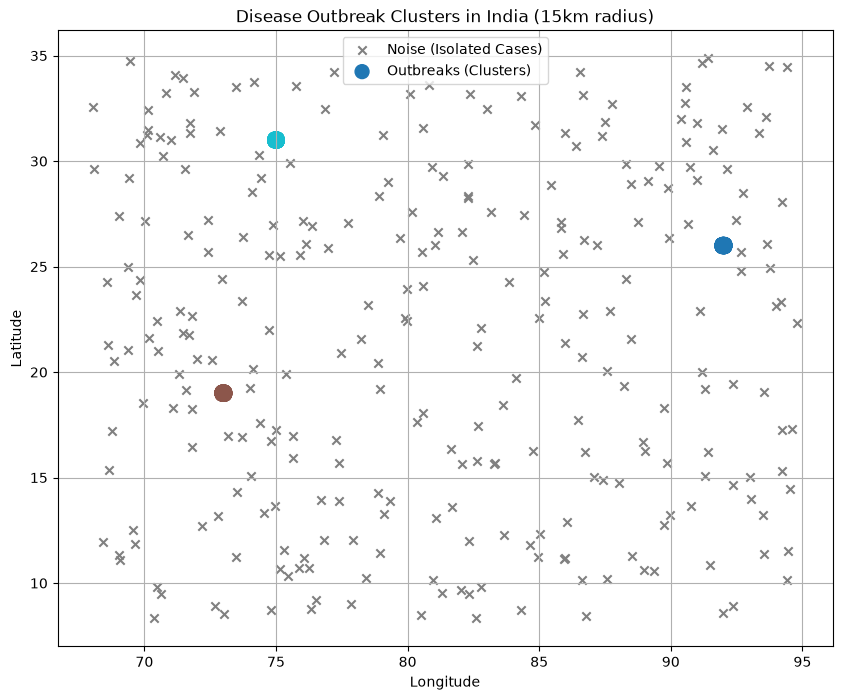

Found 3 distinct outbreaks!


In [7]:
from sklearn.cluster import DBSCAN
import math
import matplotlib.pyplot as plt

# 1. Fetch the geographical data from our field_reports table
df_geo = pd.read_sql_query('SELECT report_id, latitude, longitude FROM field_reports WHERE latitude IS NOT NULL;', conn)

if len(df_geo) > 0:
    # 2. Prepare data for Haversine metric (requires radians)
    coords = np.radians(df_geo[['latitude', 'longitude']].values)
    
    # 3. Configure DBSCAN (eps = 15km / Earth radius in km)
    earth_radius_km = 6371.0
    epsilon = 15.0 / earth_radius_km
    
    db = DBSCAN(eps=epsilon, min_samples=3, algorithm='ball_tree', metric='haversine').fit(coords)
    df_geo['cluster_id'] = db.labels_
    
    # 4. Plot the results!
    plt.figure(figsize=(10, 8))
    
    # Plot Noise (cluster_id = -1)
    noise = df_geo[df_geo['cluster_id'] == -1]
    plt.scatter(noise['longitude'], noise['latitude'], c='grey', marker='x', label='Noise (Isolated Cases)')
    
    # Plot real clusters (outbreaks)
    clusters = df_geo[df_geo['cluster_id'] != -1]
    scatter = plt.scatter(clusters['longitude'], clusters['latitude'], c=clusters['cluster_id'], cmap='tab10', s=100, label='Outbreaks (Clusters)')
    
    plt.title('Disease Outbreak Clusters in India (15km radius)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"Found {len(df_geo['cluster_id'].unique()) - (1 if -1 in df_geo['cluster_id'].values else 0)} distinct outbreaks!")
else:
    print("No spatial data found in the database.")


## 8. Image Classification Model (ResNet CNN)
We have successfully downloaded a real dataset of 1,024 images of Cattle (`Lumpy Skin` vs `Normal Skin`). 
Let's build a Deep Learning Computer Vision model (ResNet18) to classify these images. We will use Transfer Learning to drastically speed up the training process!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Define Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Load the Dataset
data_dir = "../data/Lumpy Skin Images Dataset"
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split into Train and Validation (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Loaded {len(dataset)} images across classes: {dataset.classes}")

# 3. Initialize Pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the final layer for 2 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))

# 4. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Train the Model! (Demo: 5 Epochs)
print(f"Training on {device}...")
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

print("Training Complete!")

# 6. Save Model weights for the FastAPI backend
# torch.save(model.state_dict(), "model_registry/lumpy_cnn_v1.pth")

Loaded 1024 images across classes: ['Lumpy Skin', 'Normal Skin']
Training on cpu...
